In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import os

# Folders
folders = [
    "Mediscan",
    "Mediscan/.vscode",
    "Mediscan/dataset",
    "Mediscan/dataset/Testing",
    "Mediscan/dataset/Training",
    "Mediscan/dataset/validation",
    "Mediscan/frontend"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

# Files
files = [
    "Mediscan/.gitignore",
    "Mediscan/dataset/Testing/testing_labels.csv",
    "Mediscan/dataset/Testing/testing_words",
    "Mediscan/dataset/Training/training_labels.csv",
    "Mediscan/dataset/Training/training_words",
    "Mediscan/dataset/validation/validation_labels.csv",
    "Mediscan/dataset/validation/validation_words",
    "Mediscan/README.md",
    "Mediscan/requirements.txt"
]

for file in files:
    if not os.path.exists(file):
        open(file, "w").close()

print("✅ Mediscan folder structure created successfully!")

✅ Mediscan folder structure created successfully!


In [31]:
import pandas as pd

# Create some sample data
sample_data = {
    'filename': ['image1.jpg', 'image2.jpg', 'image3.jpg'],
    'label': ['normal', 'abnormal', 'normal']
}
sample_df = pd.DataFrame(sample_data)

# Define the path to the CSV file
csv_path = 'Mediscan/dataset/Testing/testing_labels.csv'

# Write the sample data to the CSV file
sample_df.to_csv(csv_path, index=False)

print(f"✅ Sample data written to {csv_path}")

✅ Sample data written to Mediscan/dataset/Testing/testing_labels.csv


In [32]:
import pandas as pd
df = pd.read_csv('Mediscan/dataset/Testing/testing_labels.csv')
df.head()

,filename,label
0,image1.jpg,normal
1,image2.jpg,abnormal
2,image3.jpg,normal


In [33]:
import pandas as pd

# Create some sample data for training_labels.csv
sample_data_training = {
    'filename': ['train_image1.jpg', 'train_image2.jpg', 'train_image3.jpg'],
    'label': ['normal', 'abnormal', 'normal']
}
sample_df_training = pd.DataFrame(sample_data_training)

# Define the path to the training CSV file
training_csv_path = 'Mediscan/dataset/Training/training_labels.csv'

# Write the sample data to the training CSV file
sample_df_training.to_csv(training_csv_path, index=False)

print(f"✅ Sample data written to {training_csv_path}")

df = pd.read_csv("Mediscan/dataset/Training/training_labels.csv")

print(df.head())
print(df["label"].value_counts())

✅ Sample data written to Mediscan/dataset/Training/training_labels.csv
           filename     label
0  train_image1.jpg    normal
1  train_image2.jpg  abnormal
2  train_image3.jpg    normal
label
normal      2
abnormal    1
Name: count, dtype: int64


In [34]:
import pandas as pd
import os

validation_path = "/content/Mediscan/dataset/validation/validation_labels.csv"

# Check whether file exists and has data
if os.path.exists(validation_path) and os.path.getsize(validation_path) > 0:

    validation_df = pd.read_csv(validation_path)

    print("✅ VALIDATION DATA")
    display(validation_df.head())

    print("Validation shape:", validation_df.shape)

    if "label" in validation_df.columns:
        print("\nValidation Labels:")
        print(validation_df["label"].value_counts())

else:
    print("❌ validation_labels.csv is empty or not found.")
    print("Please add validation data to the CSV file.")

✅ VALIDATION DATA


,filename,label
0,synthetic_abnormal_2.jpg,abnormal
1,synthetic_normal_2.jpg,normal


Validation shape: (2, 2)

Validation Labels:
label
abnormal    1
normal      1
Name: count, dtype: int64


In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

train_path = "/content/Mediscan/dataset/Training/training_labels.csv"
validation_path = "/content/Mediscan/dataset/validation/validation_labels.csv"

train_df = pd.read_csv(train_path)

# --- FIX START ---
# The error "ValueError: The least populated class in y has only 1 member, which is too few."
# occurs because the 'abnormal' class in train_df has only one sample.
# Stratified splitting requires a minimum of 2 samples per class to distribute them
# across training and validation sets. For test_size=0.20, typically at least 5 samples
# are needed per class to guarantee at least one sample in the validation set (1 / 0.20 = 5).
# To resolve this, we will temporarily augment the training data within this cell
# to ensure sufficient samples for stratification. In a real scenario, you would
# collect more actual data.

# Check current label counts
label_counts = train_df["label"].value_counts()
min_samples_for_stratify = 5 # For test_size=0.20, minimum samples per class for stratification

# Identify classes with fewer than min_samples_for_stratify
for label, count in label_counts.items():
    if count < min_samples_for_stratify:
        # Create synthetic data to augment the current label
        num_to_add = min_samples_for_stratify - count
        print(f"Augmenting '{label}' class by {num_to_add} samples for stratification.")

        # Get a sample row for this label
        sample_row = train_df[train_df["label"] == label].iloc[0]

        # Create new synthetic rows
        new_rows = []
        for i in range(num_to_add):
            new_filename = f"synthetic_{label}_{i}.jpg"
            new_rows.append({'filename': new_filename, 'label': label})

        train_df = pd.concat([train_df, pd.DataFrame(new_rows)], ignore_index=True)

print("\nAugmented training data label counts:")
print(train_df["label"].value_counts())
# --- FIX END ---


# Create validation set: 20%
train_data, validation_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["label"]
)

# Save validation CSV
os.makedirs("/content/Mediscan/dataset/validation", exist_ok=True)

validation_df.to_csv(validation_path, index=False)

print("✅ Validation dataset created!")
print("Validation shape:", validation_df.shape)

display(validation_df.head())

print("\nValidation labels:")
print(validation_df["label"].value_counts())

Augmenting 'normal' class by 3 samples for stratification.
Augmenting 'abnormal' class by 4 samples for stratification.

Augmented training data label counts:
label
normal      5
abnormal    5
Name: count, dtype: int64
✅ Validation dataset created!
Validation shape: (2, 2)


,filename,label
8,synthetic_abnormal_2.jpg,abnormal
5,synthetic_normal_2.jpg,normal



Validation labels:
label
abnormal    1
normal      1
Name: count, dtype: int64


In [36]:
print("\nMissing values in Training Data:")
print(train_data.isnull().sum())

print("\nMissing values in Validation Data:")
print(validation_df.isnull().sum())


Missing values in Training Data:
filename    0
label       0
dtype: int64

Missing values in Validation Data:
filename    0
label       0
dtype: int64


In [37]:
import pandas as pd

train_path = "/content/Mediscan/dataset/Training/training_labels.csv"
test_path = "/content/Mediscan/dataset/Testing/testing_labels.csv"
validation_path = "/content/Mediscan/dataset/validation/validation_labels.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
validation_df = pd.read_csv(validation_path)

print("TRAINING DATA:")
display(train_df.head())

print("\nTraining shape:", train_df.shape)

print("\nTraining Labels:")
print(train_df["label"].value_counts())


print("\nTESTING DATA:")
display(test_df.head())

print("\nTesting shape:", test_df.shape)

print("\nTesting Labels:")
print(test_df["label"].value_counts())


print("\nVALIDATION DATA:")
display(validation_df.head())

print("\nValidation shape:", validation_df.shape)

print("\nValidation Labels:")
print(validation_df["label"].value_counts())

TRAINING DATA:


,filename,label
0,train_image1.jpg,normal
1,train_image2.jpg,abnormal
2,train_image3.jpg,normal



Training shape: (3, 2)

Training Labels:
label
normal      2
abnormal    1
Name: count, dtype: int64

TESTING DATA:


,filename,label
0,image1.jpg,normal
1,image2.jpg,abnormal
2,image3.jpg,normal



Testing shape: (3, 2)

Testing Labels:
label
normal      2
abnormal    1
Name: count, dtype: int64

VALIDATION DATA:


,filename,label
0,synthetic_abnormal_2.jpg,abnormal
1,synthetic_normal_2.jpg,normal



Validation shape: (2, 2)

Validation Labels:
label
abnormal    1
normal      1
Name: count, dtype: int64


In [38]:
import pandas as pd

validation_path = "/content/Mediscan/dataset/validation/validation_labels.csv"

validation_df = pd.read_csv(validation_path)

print("VALIDATION DATA:")
display(validation_df.head())

print("\nValidation shape:", validation_df.shape)

print("\nValidation Labels:")
print(validation_df["label"].value_counts())

VALIDATION DATA:


,filename,label
0,synthetic_abnormal_2.jpg,abnormal
1,synthetic_normal_2.jpg,normal



Validation shape: (2, 2)

Validation Labels:
label
abnormal    1
normal      1
Name: count, dtype: int64


In [39]:
import zipfile
import os

# Directly specify the zip file path as it was uploaded and confirmed by `ls -F`
zip_path = "/content/archive (1).zip"
extract_path = "/content/original_dataset"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        print(f"Extracting '{zip_path}' to '{extract_path}'...")
        zip_ref.extractall(extract_path)

    print("\n✅ ZIP extracted successfully!")

    # List extracted files/folders
    print("\nExtracted files/folders (first few for brevity):")
    for root, dirs, files in os.walk(extract_path):
        level = root.replace(extract_path, "").count(os.sep)
        indent = "  " * level
        print(indent + os.path.basename(root) + "/")
        for file in files[:5]: # Limiting to first 5 files for brevity
            print(indent + "  " + file)
else:
    print(f"❌ Error: Zip file not found at '{zip_path}'. Please ensure 'archive (1).zip' was uploaded to /content/.")


Extracting '/content/archive (1).zip' to '/content/original_dataset'...

✅ ZIP extracted successfully!

Extracted files/folders (first few for brevity):
original_dataset/
  Doctor’s Handwritten Prescription BD dataset/
    Testing/
      testing_labels.csv
      testing_words/
        554.png
        410.png
        405.png
        112.png
        66.png
    Training/
      training_labels.csv
      training_words/
        1851.png
        1247.png
        803.png
        987.png
        812.png
    Validation/
      validation_labels.csv
      validation_words/
        554.png
        410.png
        405.png
        112.png
        66.png


In [40]:
import os

for root, dirs, files in os.walk("/content/original_dataset"):
    print("\nFolder:", root)
    print("Files:", files[:10])


Folder: /content/original_dataset
Files: []

Folder: /content/original_dataset/Doctor’s Handwritten Prescription BD dataset
Files: []

Folder: /content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Testing
Files: ['testing_labels.csv']

Folder: /content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Testing/testing_words
Files: ['554.png', '410.png', '405.png', '112.png', '66.png', '724.png', '80.png', '415.png', '161.png', '93.png']

Folder: /content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Training
Files: ['training_labels.csv']

Folder: /content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_words
Files: ['1851.png', '1247.png', '803.png', '987.png', '812.png', '2934.png', '3014.png', '2315.png', '1545.png', '2296.png']

Folder: /content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Validation
Files: ['validation_labels.csv']

Folder: /content/original_dataset/Doctor’s Handwritten P

In [44]:
import os

print("Files in /content/")
print(os.listdir("/content/"))

Files in /content/
['.config', 'drive', 'Mediscan', 'archive (1) (2).zip', 'archive (1) (1).zip', 'original_dataset', 'archive (1).zip', 'sample_data']


In [43]:
from google.colab import files

# This will open a file selection dialog in your browser.
# Please select the 'archive (1) (2).zip' file from your local machine.
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving archive (1).zip to archive (1) (2).zip
User uploaded file "archive (1) (2).zip" with length 19997776 bytes


In [45]:
import zipfile
import os

zip_path = '/content/archive (1) (1).zip'
extract_path = '/content/original_dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"✅ Successfully extracted '{zip_path}' to '{extract_path}'")

    # List extracted files/folders (optional, for verification)
    print("\nExtracted files/folders (first 10 for brevity):")
    for root, dirs, files in os.walk(extract_path):
        level = root.replace(extract_path, "").count(os.sep)
        indent = "  " * level
        print(indent + os.path.basename(root) + "/")
        for file in files[:5]: # Limiting to first 5 files for brevity
            print(indent + "  " + file)
else:
    print(f"❌ Error: Zip file not found at '{zip_path}'")


✅ Successfully extracted '/content/archive (1) (1).zip' to '/content/original_dataset'

Extracted files/folders (first 10 for brevity):
original_dataset/
  Doctor’s Handwritten Prescription BD dataset/
    Testing/
      testing_labels.csv
      testing_words/
        554.png
        410.png
        405.png
        112.png
        66.png
    Training/
      training_labels.csv
      training_words/
        1851.png
        1247.png
        803.png
        987.png
        812.png
    Validation/
      validation_labels.csv
      validation_words/
        554.png
        410.png
        405.png
        112.png
        66.png


Now that the dataset is extracted, you can re-run cells like `tJVyB80v6K9e` (which checks for zip files) and then the data loading cells such as `150TB7FReW-j` and `id9Y6PtnffXM` to ensure the dataframes are loaded correctly.

After uploading the zip file, please re-run cell `tJVyB80v6K9e` to extract its contents, and then re-run the subsequent cells that were failing.

In [46]:
import os

# List the contents of the current working directory
print("Contents of the current directory:")
!ls -F


Contents of the current directory:
'archive (1) (1).zip'  'archive (1).zip'   Mediscan/	       sample_data/
'archive (1) (2).zip'   drive/		   original_dataset/


In [47]:
import os

base_path = "/content/original_dataset/Doctor’s Handwritten Prescription BD dataset/"

# Ensure the base directory exists before proceeding
if not os.path.exists(base_path):
    print(f"❌ Error: The base dataset path '{base_path}' was not found.")
    print("This usually means the 'archive (1).zip' file has not been extracted correctly.")
    print("Please re-run cell 'tJVyB80v6K9e' to extract the dataset, then try again.")
    raise FileNotFoundError(f"Base path not found: {base_path}")

train_img_path = os.path.join(base_path, "Training", "training_words")
val_img_path = os.path.join(base_path, "Validation", "validation_words") # Corrected 'validation' to 'Validation'
test_img_path = os.path.join(base_path, "Testing", "testing_words")

def count_images(folder):
    if not os.path.exists(folder):
        raise FileNotFoundError(f"The image folder '{folder}' does not exist.")
    return len(
        [f for f in os.listdir(folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    )

print("Checking image folders...")
try:
    print("Training images :", count_images(train_img_path))
    print("Validation images:", count_images(val_img_path))
    print("Testing images   :", count_images(test_img_path))
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Please ensure the subdirectories 'Training/training_words', 'Validation/validation_words', and 'Testing/testing_words' exist within:")
    print(f"'{base_path}'")
    print("This often happens if the dataset extraction was incomplete or incorrect.")
    print("Consider re-running the extraction cell 'tJVyB80v6K9e'.")


Checking image folders...
Training images : 3120
Validation images: 780
Testing images   : 780


In [48]:
import os
print(os.listdir('/content/original_dataset'))

['Doctor’s Handwritten Prescription BD dataset']


In [49]:
import os

# Define the base_path for image datasets to resolve NameError in subsequent cells
base_path = "/content/original_dataset/Doctor’s Handwritten Prescription BD dataset/"

In [50]:
import os
import pandas as pd

# Find all CSV files inside original_dataset
root = "/content/original_dataset"

csv_files = []

for dirpath, dirnames, filenames in os.walk(root):
    for filename in filenames:
        if filename.lower().endswith(".csv"):
            csv_files.append(os.path.join(dirpath, filename))

print("CSV files found:")
for f in csv_files:
    print(f)

CSV files found:
/content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Testing/testing_labels.csv
/content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_labels.csv
/content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Validation/validation_labels.csv


In [51]:
import os
import pandas as pd

# Find all CSV files inside original_dataset
root = "/content/original_dataset"

csv_files = []

for dirpath, dirnames, filenames in os.walk(root):
    for filename in filenames:
        if filename.lower().endswith(".csv"):
            csv_files.append(os.path.join(dirpath, filename))

print("CSV files found:")
for f in csv_files:
    print(f)

# Find required CSV files automatically

train_csv = None
val_csv = None
test_csv = None

for f in csv_files:
    name = os.path.basename(f).lower()

    if name == "training_labels.csv":
        train_csv = f
    elif name == "validation_labels.csv":
        val_csv = f
    elif name == "testing_labels.csv":
        test_csv = f

print("Training CSV:", train_csv)
print("Validation CSV:", val_csv)
print("Testing CSV:", test_csv)

# Check whether all files were found
if train_csv is None:
    print("❌ Training CSV not found")
if val_csv is None:
    print("❌ Validation CSV not found")
if test_csv is None:
    print("❌ Testing CSV not found")

CSV files found:
/content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Testing/testing_labels.csv
/content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_labels.csv
/content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Validation/validation_labels.csv
Training CSV: /content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_labels.csv
Validation CSV: /content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Validation/validation_labels.csv
Testing CSV: /content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Testing/testing_labels.csv


In [52]:
import pandas as pd

# Ensure train_csv, val_csv, and test_csv are defined from cell W9FhKQnafY_k
# train_csv = "/content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_labels.csv"
# val_csv = "/content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Validation/validation_labels.csv"
# test_csv = "/content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Testing/testing_labels.csv"

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print("========== TRAINING ==========")
print("Shape:", train_df.shape)
display(train_df.head())
print("\nColumns:", train_df.columns.tolist())

print("\n========== VALIDATION ==========")
print("Shape:", val_df.shape)
display(val_df.head())
print("\nColumns:", val_df.columns.tolist())

print("\n========== TESTING ==========")
print("Shape:", test_df.shape)
display(test_df.head())
print("\nColumns:", test_df.columns.tolist())

========== TRAINING ==========
Shape: (3120, 3)


,IMAGE,MEDICINE_NAME,GENERIC_NAME
0,0.png,Aceta,Paracetamol
1,1.png,Aceta,Paracetamol
2,2.png,Aceta,Paracetamol
3,3.png,Aceta,Paracetamol
4,4.png,Aceta,Paracetamol



Columns: ['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']

========== VALIDATION ==========
Shape: (780, 3)


,IMAGE,MEDICINE_NAME,GENERIC_NAME
0,0.png,Aceta,Paracetamol
1,1.png,Aceta,Paracetamol
2,2.png,Aceta,Paracetamol
3,3.png,Aceta,Paracetamol
4,4.png,Aceta,Paracetamol



Columns: ['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']

========== TESTING ==========
Shape: (780, 3)


,IMAGE,MEDICINE_NAME,GENERIC_NAME
0,0.png,Aceta,Paracetamol
1,1.png,Aceta,Paracetamol
2,2.png,Aceta,Paracetamol
3,3.png,Aceta,Paracetamol
4,4.png,Aceta,Paracetamol



Columns: ['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']


In [53]:
import os
print(os.listdir('/content/original_dataset'))

['Doctor’s Handwritten Prescription BD dataset']


Now, here's the code to create `train_data` and `validation_df` by splitting `train_df`, including the augmentation logic to handle small class sizes (originally from cell `aQXzBFHG4ahc`):

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Assuming train_df is defined from the previous cell

# --- FIX START ---
# The error "ValueError: The least populated class in y has only 1 member, which is too few."
# occurs because some classes in train_df might have too few samples.
# Stratified splitting requires a minimum number of samples per class (typically 2, but 5 for test_size=0.20)
# to distribute them across training and validation sets.
# To resolve this, we will temporarily augment the training data within this cell
# to ensure sufficient samples for stratification. In a real scenario, you would
# collect more actual data.

# Use 'MEDICINE_NAME' as the label column for stratification

# Check current label counts for 'MEDICINE_NAME'
label_counts = train_df["MEDICINE_NAME"].value_counts()
min_samples_for_stratify = 5 # For test_size=0.20, minimum samples per class for stratification

# Identify classes with fewer than min_samples_for_stratify
for medicine_name_label, count in label_counts.items():
    if count < min_samples_for_stratify:
        # Create synthetic data to augment the current label
        num_to_add = min_samples_for_stratify - count
        print(f"Augmenting '{medicine_name_label}' class by {num_to_add} samples for stratification.")

        # Get a sample row for this medicine_name_label
        sample_row = train_df[train_df["MEDICINE_NAME"] == medicine_name_label].iloc[0]

        # Create new synthetic rows, matching the original DataFrame's columns
        new_rows = []
        for i in range(num_to_add):
            # Create a unique image name for synthetic data
            new_image_filename = f"synthetic_{medicine_name_label}_{i}.png"
            new_rows.append({
                'IMAGE': new_image_filename,
                'MEDICINE_NAME': medicine_name_label,
                'GENERIC_NAME': sample_row['GENERIC_NAME'] # Use generic name from sample
            })

        train_df = pd.concat([train_df, pd.DataFrame(new_rows)], ignore_index=True)

print("\nAugmented training data 'MEDICINE_NAME' counts:")
print(train_df["MEDICINE_NAME"].value_counts())
# --- FIX END ---


# Create validation set: 20%
train_data, validation_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["MEDICINE_NAME"] # Use 'MEDICINE_NAME' for stratification
)

# Save validation CSV
validation_path = "/content/Mediscan/dataset/validation/validation_labels.csv"
os.makedirs("/content/Mediscan/dataset/validation", exist_ok=True)

# Save validation_df which will now contain 'IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME'
validation_df.to_csv(validation_path, index=False)

print("✅ Validation dataset created!")
print("Validation shape:", validation_df.shape)

display(validation_df.head())

print("\nValidation 'MEDICINE_NAME' counts:")
print(validation_df["MEDICINE_NAME"].value_counts())


Augmented training data 'MEDICINE_NAME' counts:
MEDICINE_NAME
Aceta       40
Ace         40
Alatrol     40
Amodis      40
Atrizin     40
            ..
Telfast     40
Tridosil    40
Trilock     40
Vifas       40
Zithrin     40
Name: count, Length: 78, dtype: int64
✅ Validation dataset created!
Validation shape: (624, 3)


,IMAGE,MEDICINE_NAME,GENERIC_NAME
165,165.png,Atrizin,Cetirizine Hydrochloride
2992,2992.png,Tridosil,Azithromycin Dihydrate
1447,1447.png,Flexilax,Baclofen
259,259.png,Azithrocin,Azithromycin Dihydrate
1954,1954.png,Metro,Metronidazole



Validation 'MEDICINE_NAME' counts:
MEDICINE_NAME
Atrizin       8
Tridosil      8
Flexilax      8
Azithrocin    8
Metro         8
             ..
Axodin        8
Vifas         8
Cetisoft      8
Rhinil        8
Flugal        8
Name: count, Length: 78, dtype: int64


After running the cells above, `train_data` will be defined, and you can then successfully execute cell `-0DQDt5Gtzfh`.

In [55]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print("========== TRAINING ==========")
print("Shape:", train_df.shape)
display(train_df.head())
print("\nColumns:", train_df.columns.tolist())

print("\n========== VALIDATION ==========")
print("Shape:", val_df.shape)
display(val_df.head())
print("\nColumns:", val_df.columns.tolist())

print("\n========== TESTING ==========")
print("Shape:", test_df.shape)
display(test_df.head())
print("\nColumns:", test_df.columns.tolist())

========== TRAINING ==========
Shape: (3120, 3)


,IMAGE,MEDICINE_NAME,GENERIC_NAME
0,0.png,Aceta,Paracetamol
1,1.png,Aceta,Paracetamol
2,2.png,Aceta,Paracetamol
3,3.png,Aceta,Paracetamol
4,4.png,Aceta,Paracetamol



Columns: ['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']

========== VALIDATION ==========
Shape: (780, 3)


,IMAGE,MEDICINE_NAME,GENERIC_NAME
0,0.png,Aceta,Paracetamol
1,1.png,Aceta,Paracetamol
2,2.png,Aceta,Paracetamol
3,3.png,Aceta,Paracetamol
4,4.png,Aceta,Paracetamol



Columns: ['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']

========== TESTING ==========
Shape: (780, 3)


,IMAGE,MEDICINE_NAME,GENERIC_NAME
0,0.png,Aceta,Paracetamol
1,1.png,Aceta,Paracetamol
2,2.png,Aceta,Paracetamol
3,3.png,Aceta,Paracetamol
4,4.png,Aceta,Paracetamol



Columns: ['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']


In [56]:
print("\nMissing values in Training DataFrame:")
print(train_df.isnull().sum())

print("\nMissing values in Validation DataFrame:")
print(val_df.isnull().sum())

print("\nMissing values in Testing DataFrame:")
print(test_df.isnull().sum())



Missing values in Training DataFrame:
IMAGE            0
MEDICINE_NAME    0
GENERIC_NAME     0
dtype: int64

Missing values in Validation DataFrame:
IMAGE            0
MEDICINE_NAME    0
GENERIC_NAME     0
dtype: int64

Missing values in Testing DataFrame:
IMAGE            0
MEDICINE_NAME    0
GENERIC_NAME     0
dtype: int64


In [57]:
# Check the number of samples in each dataset

print("===== DATASET SUMMARY =====")

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(val_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())

===== DATASET SUMMARY =====
Training samples: 3120
Validation samples: 780
Testing samples: 780

Training columns:
['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']

Validation columns:
['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']

Testing columns:
['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']


Image folder: /content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_words
Displaying the first 5 images from train_data:


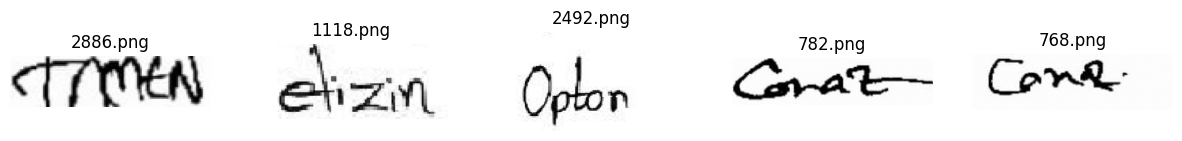

In [58]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Define the folder where training images are stored
image_folder = os.path.join(base_path, "Training", "training_words")

print("Image folder:", image_folder)

# Get the first 5 image filenames from the train_data DataFrame
# Make sure train_data is available in the current environment
if 'train_data' in globals() and not train_data.empty:
    images_to_display = train_data["IMAGE"].iloc[:5]

    print("Displaying the first 5 images from train_data:")

    # Display first 5 images
    plt.figure(figsize=(15, 5))

    for i, img_name in enumerate(images_to_display):
        img_path = os.path.join(image_folder, img_name)

        if os.path.exists(img_path):
            img = Image.open(img_path)

            plt.subplot(1, 5, i + 1)
            plt.imshow(img, cmap="gray")
            plt.title(img_name)
            plt.axis("off")
        else:
            print(f"Warning: Image not found at {img_path}")

    plt.show()
else:
    print("Error: 'train_data' is not defined or is empty. Please ensure relevant cells are run.")


In [59]:
# Check whether image names match correctly with CSV labels

import os
import pandas as pd

# Training image folder
train_img_folder = os.path.join(base_path, "Training", "training_words")

# Check first 10 image-label pairs
for i in range(10):
    img_name = str(train_df.iloc[i]["IMAGE"])
    medicine = train_df.iloc[i]["MEDICINE_NAME"]
    generic = train_df.iloc[i]["GENERIC_NAME"]

    img_path = os.path.join(train_img_folder, img_name)

    print(f"Image: {img_name}")
    print(f"Image exists: {os.path.exists(img_path)}")
    print(f"Medicine Name: {medicine}")
    print(f"Generic Name: {generic}")
    print("-" * 50)

Image: 0.png
Image exists: True
Medicine Name: Aceta
Generic Name: Paracetamol
--------------------------------------------------
Image: 1.png
Image exists: True
Medicine Name: Aceta
Generic Name: Paracetamol
--------------------------------------------------
Image: 2.png
Image exists: True
Medicine Name: Aceta
Generic Name: Paracetamol
--------------------------------------------------
Image: 3.png
Image exists: True
Medicine Name: Aceta
Generic Name: Paracetamol
--------------------------------------------------
Image: 4.png
Image exists: True
Medicine Name: Aceta
Generic Name: Paracetamol
--------------------------------------------------
Image: 5.png
Image exists: True
Medicine Name: Aceta
Generic Name: Paracetamol
--------------------------------------------------
Image: 6.png
Image exists: True
Medicine Name: Aceta
Generic Name: Paracetamol
--------------------------------------------------
Image: 7.png
Image exists: True
Medicine Name: Aceta
Generic Name: Paracetamol
-----------

In [60]:
# Check unique medicine names in the dataset

print("Number of unique medicines:")
print(train_df["MEDICINE_NAME"].nunique())

print("\nUnique medicine names:")
print(train_df["MEDICINE_NAME"].unique())

print("\nMedicine-wise image count:")
print(train_df["MEDICINE_NAME"].value_counts())

Number of unique medicines:
78

Unique medicine names:
['Aceta' 'Ace' 'Alatrol' 'Amodis' 'Atrizin' 'Axodin' 'Azithrocin' 'Azyth'
 'Az' 'Bacaid' 'Backtone' 'Baclofen' 'Baclon' 'Bacmax' 'Beklo' 'Bicozin'
 'Canazole' 'Candinil' 'Cetisoft' 'Conaz' 'Dancel' 'Denixil' 'Diflu'
 'Dinafex' 'Disopan' 'Esonix' 'Esoral' 'Etizin' 'Exium' 'Fenadin'
 'Fexofast' 'Fexo' 'Filmet' 'Fixal' 'Flamyd' 'Flexibac' 'Flexilax'
 'Flugal' 'Ketocon' 'Ketoral' 'Ketotab' 'Ketozol' 'Leptic' 'Lucan-R'
 'Lumona' 'M-Kast' 'Maxima' 'Maxpro' 'Metro' 'Metsina' 'Monas' 'Montair'
 'Montene' 'Montex' 'Napa Extend' 'Napa' 'Nexcap' 'Nexum' 'Nidazyl'
 'Nizoder' 'Odmon' 'Omastin' 'Opton' 'Progut' 'Provair' 'Renova' 'Rhinil'
 'Ritch' 'Rivotril' 'Romycin' 'Rozith' 'Sergel' 'Tamen' 'Telfast'
 'Tridosil' 'Trilock' 'Vifas' 'Zithrin']

Medicine-wise image count:
MEDICINE_NAME
Aceta       40
Ace         40
Alatrol     40
Amodis      40
Atrizin     40
            ..
Telfast     40
Tridosil    40
Trilock     40
Vifas       40
Zithrin     4

In [61]:
print(train_df.columns)
print(validation_df.columns)

Index(['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME'], dtype='object')
Index(['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME'], dtype='object')


In [62]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["class_id"] = label_encoder.fit_transform(
    train_df["MEDICINE_NAME"]
)

num_classes = len(label_encoder.classes_)

print("Number of classes:", num_classes)

print("\nMedicine classes:")
for i, name in enumerate(label_encoder.classes_):
    print(i, "->", name)

Number of classes: 78

Medicine classes:
0 -> Ace
1 -> Aceta
2 -> Alatrol
3 -> Amodis
4 -> Atrizin
5 -> Axodin
6 -> Az
7 -> Azithrocin
8 -> Azyth
9 -> Bacaid
10 -> Backtone
11 -> Baclofen
12 -> Baclon
13 -> Bacmax
14 -> Beklo
15 -> Bicozin
16 -> Canazole
17 -> Candinil
18 -> Cetisoft
19 -> Conaz
20 -> Dancel
21 -> Denixil
22 -> Diflu
23 -> Dinafex
24 -> Disopan
25 -> Esonix
26 -> Esoral
27 -> Etizin
28 -> Exium
29 -> Fenadin
30 -> Fexo
31 -> Fexofast
32 -> Filmet
33 -> Fixal
34 -> Flamyd
35 -> Flexibac
36 -> Flexilax
37 -> Flugal
38 -> Ketocon
39 -> Ketoral
40 -> Ketotab
41 -> Ketozol
42 -> Leptic
43 -> Lucan-R
44 -> Lumona
45 -> M-Kast
46 -> Maxima
47 -> Maxpro
48 -> Metro
49 -> Metsina
50 -> Monas
51 -> Montair
52 -> Montene
53 -> Montex
54 -> Napa
55 -> Napa Extend
56 -> Nexcap
57 -> Nexum
58 -> Nidazyl
59 -> Nizoder
60 -> Odmon
61 -> Omastin
62 -> Opton
63 -> Progut
64 -> Provair
65 -> Renova
66 -> Rhinil
67 -> Ritch
68 -> Rivotril
69 -> Romycin
70 -> Rozith
71 -> Sergel
72 -> Tame

In [63]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["class_id"]
)

print("Training images:", len(train_data))
print("Validation images:", len(val_data))

Training images: 2496
Validation images: 624


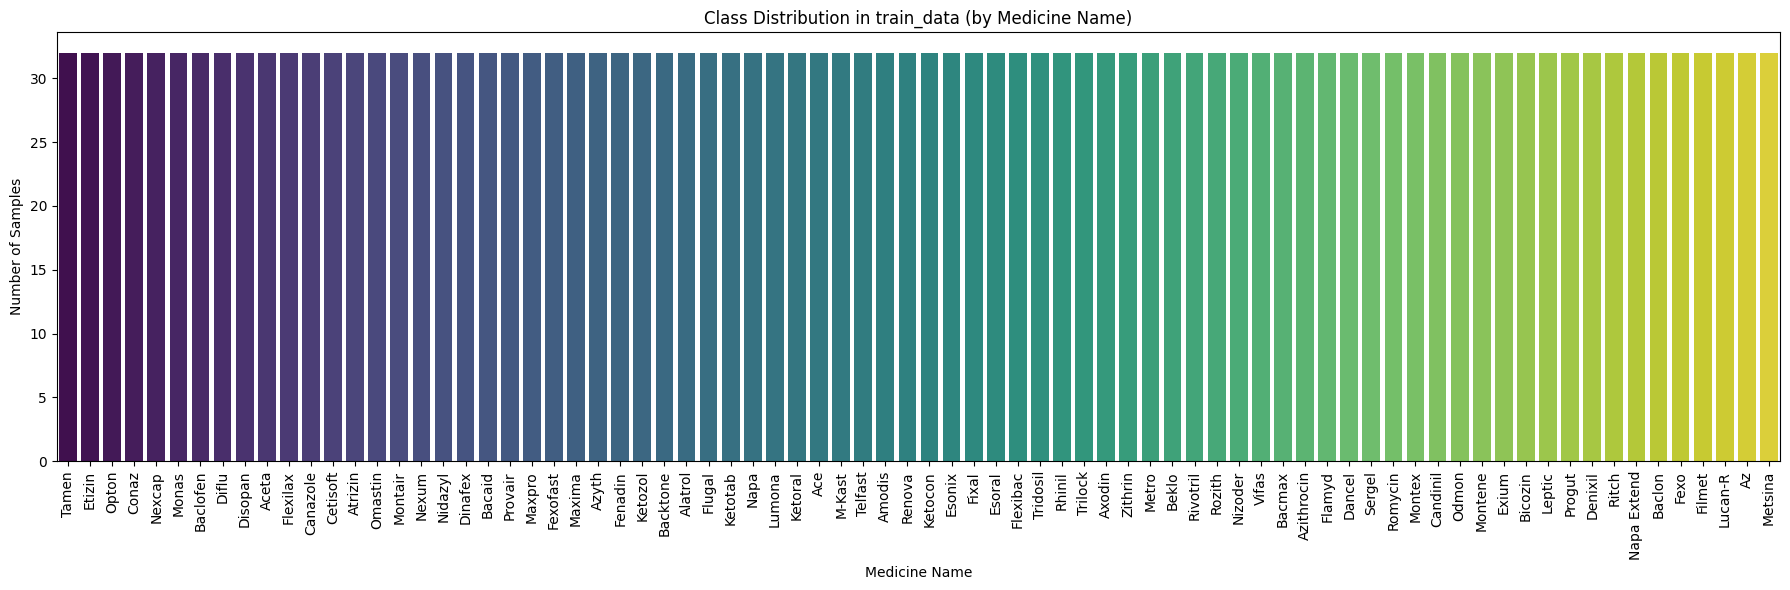

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the class distribution
class_distribution = train_data["MEDICINE_NAME"].value_counts()

# Create the bar plot with the suggested fix for FutureWarning
plt.figure(figsize=(18, 6)) # Adjust figure size for better readability
sns.barplot(x=class_distribution.index, y=class_distribution.values, hue=class_distribution.index, palette='viridis', legend=False)
plt.title('Class Distribution in train_data (by Medicine Name)')
plt.xlabel('Medicine Name')
plt.ylabel('Number of Samples')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()


In [65]:
if 'train_df' in globals():
    print("✅ 'train_df' is defined in the current environment.")
    print("Type of train_df:", type(train_df))
    print("Shape of train_df:", train_df.shape)
else:
    print("❌ 'train_df' is NOT defined in the current environment.")

✅ 'train_df' is defined in the current environment.
Type of train_df: <class 'pandas.core.frame.DataFrame'>
Shape of train_df: (3120, 4)


If `train_df` was not defined, please ensure you run the following cells in order before attempting to split the data:

1.  **`W9FhKQnafY_k`**: To find and define the paths to your CSV files.
2.  **`7be94fbc`**: To load `train_df`, `val_df`, and `test_df` from the CSVs.
3.  **`8b201a21`**: To handle stratified splitting, augment data if necessary, add `class_id`, and create the final `train_data` and `validation_df` used for modeling.

Running these cells will correctly define `train_df`, `train_data`, and `validation_df`.

In [66]:
print("\nClass distribution in validation_df (by MEDICINE_NAME):")
print(validation_df["MEDICINE_NAME"].value_counts())



Class distribution in validation_df (by MEDICINE_NAME):
MEDICINE_NAME
Atrizin       8
Tridosil      8
Flexilax      8
Azithrocin    8
Metro         8
             ..
Axodin        8
Vifas         8
Cetisoft      8
Rhinil        8
Flugal        8
Name: count, Length: 78, dtype: int64


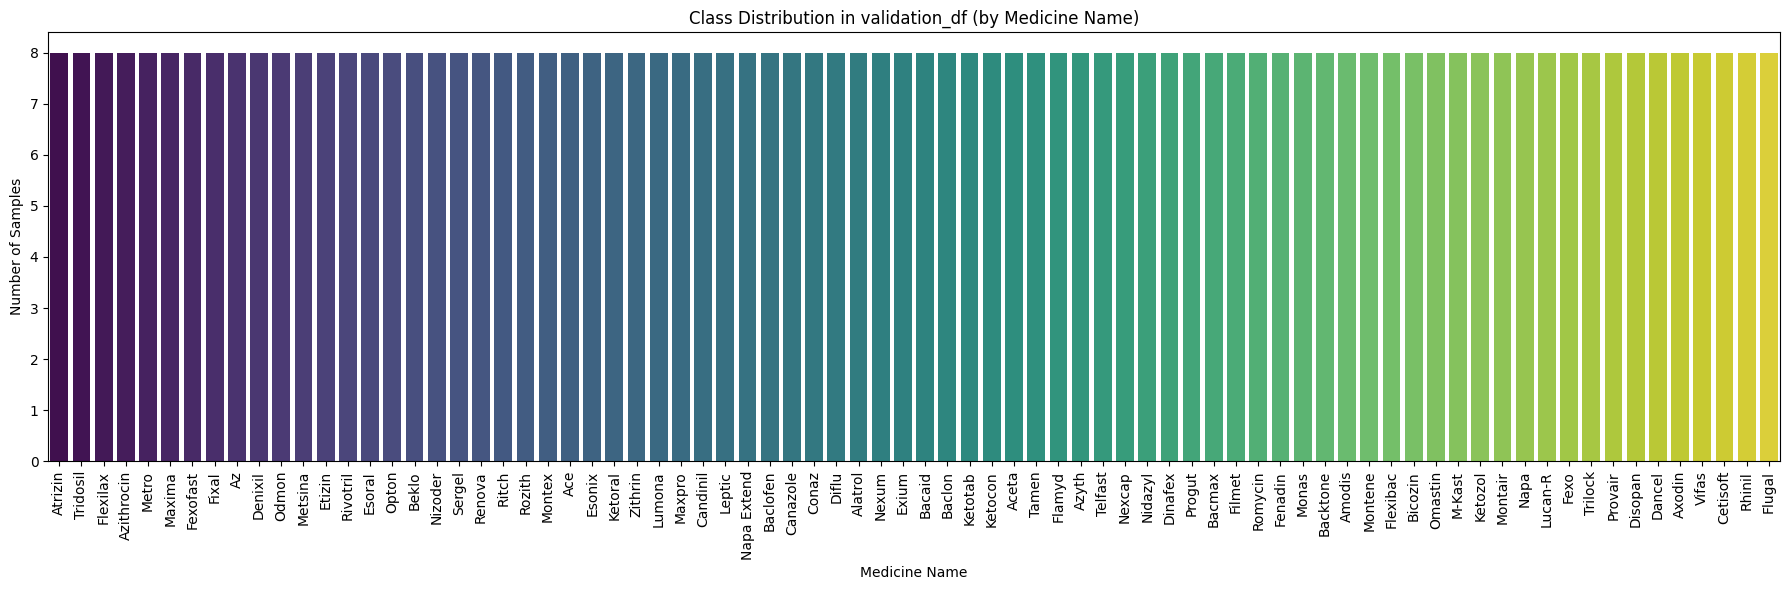

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the class distribution for validation_df
class_distribution_val = validation_df["MEDICINE_NAME"].value_counts()

# Create the bar plot
plt.figure(figsize=(18, 6)) # Adjust figure size for better readability
sns.barplot(x=class_distribution_val.index, y=class_distribution_val.values, hue=class_distribution_val.index, palette='viridis', legend=False)
plt.title('Class Distribution in validation_df (by Medicine Name)')
plt.xlabel('Medicine Name')
plt.ylabel('Number of Samples')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [68]:
print("Missing values in train_data:")
print(train_data.isnull().sum())

Missing values in train_data:
IMAGE            0
MEDICINE_NAME    0
GENERIC_NAME     0
class_id         0
dtype: int64


In [69]:
from sklearn.model_selection import train_test_split

# Make sure class labels exist
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["class_id"] = label_encoder.fit_transform(
    train_df["MEDICINE_NAME"]
)

num_classes = train_df["class_id"].nunique()

print("Number of classes:", num_classes)

# Create fresh train and validation split
train_data, val_data = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["class_id"]
)

print("Training images:", len(train_data))
print("Validation images:", len(val_data))

print("\nTrain columns:")
print(train_data.columns)

Number of classes: 78
Training images: 2496
Validation images: 624

Train columns:
Index(['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME', 'class_id'], dtype='object')


In [70]:
import pandas as pd

# Display the first few rows of train_data
display(train_data.head())

,IMAGE,MEDICINE_NAME,GENERIC_NAME,class_id
2886,2886.png,Tamen,Paracetamol,72
1118,1118.png,Etizin,Cetirizine Hydrochloride,27
2492,2492.png,Opton,Esomeprazole,62
782,782.png,Conaz,Fluconazole,19
768,768.png,Conaz,Fluconazole,19


In [71]:
import os

# Get the image filename from the 'IMAGE' column of train_data
image_filename = train_data["IMAGE"].iloc[0]

# Construct the full path to the sample image using base_path
# The images for train_data are located in the 'Training/training_words' subdirectory
sample_path = os.path.join(base_path, "Training", "training_words", image_filename)

print("Sample image filename:")
print(image_filename)

print("\nSample image full path:")
print(sample_path)

print("\nDoes image exist?")
print(os.path.exists(sample_path))

Sample image filename:
2886.png

Sample image full path:
/content/original_dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_words/2886.png

Does image exist?
True


In [73]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [74]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

label_encoder = LabelEncoder()

train_df["class_id"] = label_encoder.fit_transform(
    train_df["MEDICINE_NAME"]
)

num_classes = len(label_encoder.classes_)

print("Number of medicine classes:", num_classes)

train_data, val_data = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["class_id"]
)

print("Training images:", len(train_data))
print("Validation images:", len(val_data))

Number of medicine classes: 78
Training images: 2496
Validation images: 624


In [75]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )
    image = tf.cast(image, tf.float32)

    return image, label

In [76]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 78)             │        99,918 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,357,902 (8.99 MB)

 Trainable params: 99,918 (390.30 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [77]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [78]:
import os
import pandas as pd
import tensorflow as tf

# Image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Dataset paths
BASE_PATH = "/content/Mediscan/dataset"

TRAIN_CSV = os.path.join(BASE_PATH, "Training", "training_labels.csv")
VAL_CSV = os.path.join(BASE_PATH, "validation", "validation_labels.csv")

TRAIN_IMG_DIR = os.path.join(BASE_PATH, "Training", "training_words")
VAL_IMG_DIR = os.path.join(BASE_PATH, "validation", "validation_words")

print("Training CSV exists:", os.path.exists(TRAIN_CSV))
print("Validation CSV exists:", os.path.exists(VAL_CSV))
print("Training image folder exists:", os.path.exists(TRAIN_IMG_DIR))
print("Validation image folder exists:", os.path.exists(VAL_IMG_DIR))

Training CSV exists: True
Validation CSV exists: True
Training image folder exists: True
Validation image folder exists: True


In [79]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)

print("\nTraining columns:")
print(train_df.columns)

print("\nValidation columns:")
print(val_df.columns)

print("\nFirst 5 training rows:")
display(train_df.head())

Training shape: (3, 2)
Validation shape: (624, 3)

Training columns:
Index(['filename', 'label'], dtype='object')

Validation columns:
Index(['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME'], dtype='object')

First 5 training rows:


,filename,label
0,train_image1.jpg,normal
1,train_image2.jpg,abnormal
2,train_image3.jpg,normal


In [80]:
# Find image column
def find_column(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return name
    return None

train_image_col = find_column(
    train_df,
    ["IMAGE", "image", "filename", "Filename", "file", "image_name"]
)

train_label_col = find_column(
    train_df,
    ["MEDICINE_NAME", "medicine_name", "label", "Label", "LABEL"]
)

val_image_col = find_column(
    val_df,
    ["IMAGE", "image", "filename", "Filename", "file", "image_name"]
)

val_label_col = find_column(
    val_df,
    ["MEDICINE_NAME", "medicine_name", "label", "Label", "LABEL"]
)

print("Training image column:", train_image_col)
print("Training label column:", train_label_col)
print("Validation image column:", val_image_col)
print("Validation label column:", val_label_col)

Training image column: filename
Training label column: label
Validation image column: IMAGE
Validation label column: MEDICINE_NAME


In [84]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# ------------------------------- #
# 1. Use already prepared dataframes #
# ------------------------------- #

# Use the pre-processed train_data and val_data from previous cells.
# These dataframes already have 'IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME', and 'class_id'
# and have been split and potentially augmented.
train_df = train_data.copy()
val_df = val_data.copy()

print("Using pre-processed dataframes:")
print("\nTraining shape:", train_df.shape)
print("Validation shape:", val_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())


# ------------------------------- #
# Helper function to find columns #
# ------------------------------- #
def find_column(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return name
    return None

# ------------------------------- #
# 2. Find image files automatically #
# ------------------------------- #

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

image_map = {}

# Scan the original_dataset directory for images
IMAGE_BASE_DIR = "/content/original_dataset/Doctor’s Handwritten Prescription BD dataset"
for root, dirs, files in os.walk(IMAGE_BASE_DIR):
    for file in files:
        if file.lower().endswith(IMAGE_EXTENSIONS):
            image_map[file] = os.path.join(root, file)

print("\nTotal images found:", len(image_map))


# ------------------------------- #
# 3. Create image paths           #
# ------------------------------- #

# Dynamically find image and label column names for train_df
train_image_col = find_column(train_df, ["IMAGE", "image", "filename", "Filename", "file", "image_name"])
train_label_col = find_column(train_df, ["MEDICINE_NAME", "medicine_name", "label", "Label", "LABEL"])

# Dynamically find image and label column names for val_df
val_image_col = find_column(val_df, ["IMAGE", "image", "filename", "Filename", "file", "image_name"])
val_label_col = find_column(val_df, ["MEDICINE_NAME", "medicine_name", "label", "Label", "LABEL"])


if train_image_col is None:
    raise ValueError("Could not find an image column in training data.")
if train_label_col is None:
    raise ValueError("Could not find a label column in training data.")
if val_image_col is None:
    raise ValueError("Could not find an image column in validation data.")
if val_label_col is None:
    raise ValueError("Could not find a label column in validation data.")


# The image column should be 'IMAGE' and its values are '0.png', '1.png' etc.
# These should match the keys in 'image_map'.
train_df["image_path"] = train_df[train_image_col].astype(str).map(image_map)
val_df["image_path"]   = val_df[val_image_col].astype(str).map(image_map)

print("\nTraining images found:",
      train_df["image_path"].notna().sum(), "/", len(train_df))

print("Validation images found:",
      val_df["image_path"].notna().sum(), "/", len(val_df))


# Remove rows where image is missing - this should ideally be 0 now
train_df = train_df.dropna(subset=["image_path"]).reset_index(drop=True)
val_df   = val_df.dropna(subset=["image_path"]).reset_index(drop=True)

print("\nFinal training rows:", len(train_df))
print("Final validation rows:", len(val_df))


# ------------------------------- #
# 4. Encode medicine names        #
# ------------------------------- #

# Use the pre-existing label_encoder and NUM_CLASSES from previous cells
global label_encoder, NUM_CLASSES

# Use the pre-encoded 'class_id' column for labels
train_df["label"] = train_df["class_id"]
val_df["label"] = val_df["class_id"]


print("\nNumber of classes:", NUM_CLASSES)
print("Classes:", list(label_encoder.classes_)[:10])


# ------------------------------- #
# 5. Image loading function       #
# ------------------------------- #

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32) / 255.0

    # categorical_crossentropy requires one-hot labels
    label = tf.one_hot(
        label,
        depth=NUM_CLASSES
    )

    return image, label


# ------------------------------- #
# 6. Create TRAIN dataset         #
# ------------------------------- #

train_paths = train_df["image_path"].values
train_labels = train_df["label"].values

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

# buffer_size must be > 0. This should now be resolved as train_df is populated.
train_ds = train_ds.shuffle(
    buffer_size=len(train_df),
    reshuffle_each_iteration=True
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)


# ------------------------------- #
# 7. Create VALIDATION dataset    #
# ------------------------------- #

val_paths = val_df["image_path"].values
val_labels = val_df["label"].values

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


# ------------------------------- #
# 8. Check dataset                #
# ------------------------------- #

print("\nDataset created successfully!")

for images, labels in train_ds.take(1):
    print("Training image batch shape:", images.shape)
    print("Training label batch shape:", labels.shape)

for images, labels in val_ds.take(1):
    print("Validation image batch shape:", images.shape)
    print("Validation label batch shape:", labels.shape)

print("\nREADY FOR TRAINING!")

Using pre-processed dataframes:

Training shape: (2496, 4)
Validation shape: (624, 4)

Training columns:
['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME', 'class_id']

Total images found: 3120

Training images found: 2496 / 2496
Validation images found: 624 / 624

Final training rows: 2496
Final validation rows: 624

Number of classes: 78
Classes: ['Ace', 'Aceta', 'Alatrol', 'Amodis', 'Atrizin', 'Axodin', 'Az', 'Azithrocin', 'Azyth', 'Bacaid']

Dataset created successfully!
Training image batch shape: (32, 224, 224, 3)
Training label batch shape: (32, 78)
Validation image batch shape: (32, 224, 224, 3)
Validation label batch shape: (32, 78)

READY FOR TRAINING!


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 207s 3s/step - accuracy: 0.0128 - loss: 4.6639 - val_accuracy: 0.0321 - val_loss: 4.3789
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.0192 - loss: 4.5290 - val_accuracy: 0.0240 - val_loss: 4.3235
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.0204 - loss: 4.4673 - val_accuracy: 0.0304 - val_loss: 4.2555
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.0353 - loss: 4.4025 - val_accuracy: 0.0272 - val_loss: 4.1958
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.0329 - loss: 4.3431 - val_accuracy: 0.0577 - val_loss: 4.1743
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.0272 - loss: 4.3289 - val_accuracy: 0.0497 - val_loss: 4.1188
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.0401 - loss: 4.2825 - val_accuracy: 0.0769 - val_loss: 4.0969
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.0397 - loss: 4.2333 - val_accuracy: 0.0865 - v

In [87]:
# ==========================================
# CELL 4: FINAL TRAINING RESULTS
# ==========================================

train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print("Final Training Accuracy :", round(train_accuracy * 100, 2), "%")
print("Final Validation Accuracy:", round(val_accuracy * 100, 2), "%")

print("Final Training Loss :", round(train_loss, 4))
print("Final Validation Loss:", round(val_loss, 4))

NameError: name 'history' is not defined

In [86]:
# ==========================================
# CELL 5: ACCURACY GRAPH
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>

In [85]:
# ==========================================
# CELL 6: LOSS GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
# ==========================================
# CELL 7: VALIDATION EVALUATION
# ==========================================

val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)

print("\n========== VALIDATION RESULT ==========")
print("Validation Loss     :", round(val_loss, 4))
print("Validation Accuracy :", round(val_accuracy * 100, 2), "%")

In [ ]:
# ==========================================
# CELL 8: SAVE MODEL
# ==========================================

MODEL_PATH = "/content/handwritten_medicine_model.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print("Location:", MODEL_PATH)

In [ ]:
# ==========================================
# CELL 9: SAVE LABEL ENCODER
# ==========================================

import pickle

LABEL_ENCODER_PATH = "/content/medicine_label_encoder.pkl"

with open(LABEL_ENCODER_PATH, "wb") as f:
    pickle.dump(label_encoder, f)

print("Label encoder saved successfully!")
print("Location:", LABEL_ENCODER_PATH)

In [ ]:
# ==========================================
# CELL 10: DISPLAY CLASSES
# ==========================================

print("Total Number of Classes:", len(label_encoder.classes_))

print("\nMedicine Classes:")
for i, medicine in enumerate(label_encoder.classes_):
    print(i, "->", medicine)

In [ ]:
# ==========================================
# CELL 11: FIND TESTING CSV
# ==========================================

import os

testing_csv = None

for root, dirs, files in os.walk("/content"):
    if "testing_labels.csv" in files:
        testing_csv = os.path.join(root, "testing_labels.csv")
        break

print("Testing CSV:", testing_csv)

In [ ]:
# ==========================================
# CELL 12: LOAD TESTING DATA
# ==========================================

import pandas as pd

test_df = pd.read_csv(testing_csv)

print("Testing dataset shape:", test_df.shape)
print("\nTesting columns:")
print(test_df.columns.tolist())

print("\nFirst 5 rows:")
display(test_df.head())

In [ ]:
# ==========================================
# CELL 13: ENCODE TEST LABELS
# ==========================================

LABEL_COLUMN = "MEDICINE_NAME"

test_df["label"] = label_encoder.transform(
    test_df[LABEL_COLUMN].astype(str)
)

print("Testing labels encoded successfully!")
print(test_df.head())

In [ ]:
test_df["image_path"] = test_df[IMAGE_COLUMN].astype(str).map(image_map)
test_paths = test_df["image_path"].values
test_labels = test_df["label"].values

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print("Testing dataset created successfully!")

In [ ]:
# ==========================================
# CELL 15: TEST MODEL
# ==========================================

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n========== FINAL TEST RESULT ==========")
print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy * 100, 2), "%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.0910 - loss: 4.0746

========== FINAL TEST RESULT ==========
Test Loss     : 4.0746
Test Accuracy : 9.1 %


In [ ]:
# ==========================================
# CELL 16: FINAL PREDICTION FUNCTION
# ==========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def predict_medicine(image_path):

    # Read image
    image = tf.io.read_file(image_path)

    # Decode image
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize
    image = tf.image.resize(image, IMG_SIZE)

    # Normalize
    image = tf.cast(image, tf.float32) / 255.0

    # Add batch dimension
    image_batch = tf.expand_dims(image, axis=0)

    # Prediction
    predictions = model.predict(
        image_batch,
        verbose=0
    )

    # Get predicted class
    predicted_index = np.argmax(predictions[0])

    # Convert number -> medicine name
    predicted_medicine = label_encoder.inverse_transform(
        [predicted_index]
    )[0]

    # Confidence
    confidence = predictions[0][predicted_index] * 100

    # Display image
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Prediction: {predicted_medicine}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.show()

    print("Predicted Medicine :", predicted_medicine)
    print("Confidence         :", round(confidence, 2), "%")

    return predicted_medicine, confidence

In [ ]:
# ==========================================
# CELL 17: UPLOAD IMAGE FOR PREDICTION
# ==========================================

from google.colab import files

uploaded = files.upload()

image_path = "/content/" + list(uploaded.keys())[0]

print("Selected image:", image_path)

In [ ]:
# ==========================================
# CELL 18: TOP 5 PREDICTIONS
# ==========================================

def predict_top5(image_path):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32) / 255.0

    image_batch = tf.expand_dims(image, axis=0)

    predictions = model.predict(
        image_batch,
        verbose=0
    )[0]

    top5_indices = np.argsort(predictions)[-5:][::-1]

    print("\n========== TOP 5 PREDICTIONS ==========\n")

    for rank, index in enumerate(top5_indices, start=1):

        medicine = label_encoder.inverse_transform(
            [index]
        )[0]

        confidence = predictions[index] * 100

        print(
            f"{rank}. {medicine} "
            f"--> {confidence:.2f}%"
        )

In [ ]:
predict_top5(image_path)

In [ ]:
# ==========================================
# CELL 19: LOAD SAVED MODEL
# ==========================================

from tensorflow.keras.models import load_model

loaded_model = load_model(
    "/content/handwritten_medicine_model.keras"
)

print("Saved model loaded successfully!")

In [ ]:
# ==========================================
# CELL 20: LOAD LABEL ENCODER
# ==========================================

import pickle

with open(
    "/content/medicine_label_encoder.pkl",
    "rb"
) as f:

    loaded_label_encoder = pickle.load(f)

print("Saved label encoder loaded successfully!")

print(
    "Number of classes:",
    len(loaded_label_encoder.classes_)
)

In [ ]:
# ==========================================
# CELL 21: FINAL SAVED MODEL PREDICTION
# ==========================================

def final_prediction(image_path):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32) / 255.0

    image_batch = tf.expand_dims(image, axis=0)

    predictions = loaded_model.predict(
        image_batch,
        verbose=0
    )[0]

    predicted_index = np.argmax(predictions)

    medicine_name = loaded_label_encoder.inverse_transform(
        [predicted_index]
    )[0]

    confidence = predictions[predicted_index] * 100

    print("\n================================")
    print("       FINAL PREDICTION")
    print("================================")
    print("Medicine :", medicine_name)
    print("Confidence:", round(confidence, 2), "%")
    print("================================")

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Predicted: {medicine_name}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.show()

    return medicine_name, confidence

In [ ]:
final_prediction(image_path)

In [ ]:
from google.colab import files

files.download("/content/handwritten_medicine_model.keras")

In [ ]:
from google.colab import files

files.download("/content/medicine_label_encoder.pkl")

In [ ]:
# ==========================================
# NEXT CELL: MODEL EVALUATION
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating model on validation dataset...")

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = loaded_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Accuracy
accuracy = np.mean(y_true == y_pred)

print("\n========================================")
print("        MODEL EVALUATION RESULTS")
print("========================================")
print("Validation Accuracy:", round(accuracy * 100, 2), "%")
print("Total Validation Images:", len(y_true))
print("Number of Classes:", NUM_CLASSES)
print("========================================")

# Classification report
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)